# Bernstein-Vazirani Algorithm

In this module, you will:
- Understand how the **Bernstein-Vazirani (BV) algorithm** determines a hidden bitstring in a **single query** to an oracle.
- Build the BV circuit step-by-step using the QpiAI Quantum SDK — both **manually** with `Circuit` and via the high-level `BernsteinVazirani` class.
- Analyze the **mathematical foundation**: Hadamard transforms, phase kickback, and why the algorithm works.
- Run experiments on a **simulator** and verify that the measurement outcome reveals the hidden string with certainty.

## What is the Bernstein-Vazirani Algorithm?

Imagine you are given a black-box function (an *oracle*) $f:\{0,1\}^n \to \{0,1\}$ defined by:

$$f(x) = s \cdot x \pmod{2}$$

where $s \in \{0,1\}^n$ is an unknown **hidden bitstring** and $s \cdot x = \sum_i s_i x_i \pmod{2}$ is the bitwise inner product.

**The Challenge:** Given only oracle access to $f$, determine the hidden string $s$.

- **Classically**, you need **$n$ queries** — one for each bit of $s$ (query with $x = e_i$ for each standard basis vector).
- **Quantumly**, the Bernstein-Vazirani algorithm finds $s$ in **just 1 query**, an exponential speedup from $O(n)$ to $O(1)$.

**Key Insight:** The algorithm exploits two powerful quantum phenomena:
1. **Superposition** — querying the oracle with all inputs simultaneously.
2. **Phase kickback** — encoding the answer into the *phases* of the quantum state, which are then decoded by a second Hadamard transform.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 2. SDK Primitives Used (This Module)

- `BernsteinVazirani` — high-level algorithm class that builds and runs the BV circuit.
- `Circuit` — low-level circuit construction API (for manual BV circuit building).
- **Gates:** `h` (Hadamard), `x` (Pauli-X / NOT), `cx` (CNOT).
- **Circuit utilities:** `show()`, `list_gates()`.
- **Execution:** `Circuit.run(shots=..., device_name="QpiAI-QSV-Local") (Note: `experiment_name` is optional and only required for cloud executions)`.
- **Results:** `result.get_counts()`, `result.get_probabilities()`, `result.plot()`.

We will first build the circuit **manually** to understand each stage, then use the high-level `BernsteinVazirani` class for convenience.

## 3. Code: Building the Bernstein-Vazirani Circuit

The BV circuit has **five stages**:

1. **Ancilla preparation:** Apply $X$ then $H$ to the ancilla qubit to put it in the $|{-}\rangle$ state.
2. **Input superposition:** Apply $H$ to all $n$ input qubits to create a uniform superposition.
3. **Oracle:** For each bit $i$ where $s_i = 1$, apply $\text{CX}(i, \text{ancilla})$. This encodes $(-1)^{s \cdot x}$ into the phase via **phase kickback**.
4. **Decoding:** Apply $H$ to all input qubits. The Hadamard transform converts phase information back into computational basis states.
5. **Measurement:** Measure the $n$ input qubits. The result is deterministically $s$.

### 3a. Manual Construction with `Circuit`

Let's build the BV circuit for the hidden string $s = \texttt{"1011"}$ (4 qubits).

=== Manual BV Circuit for s = 1011 ===


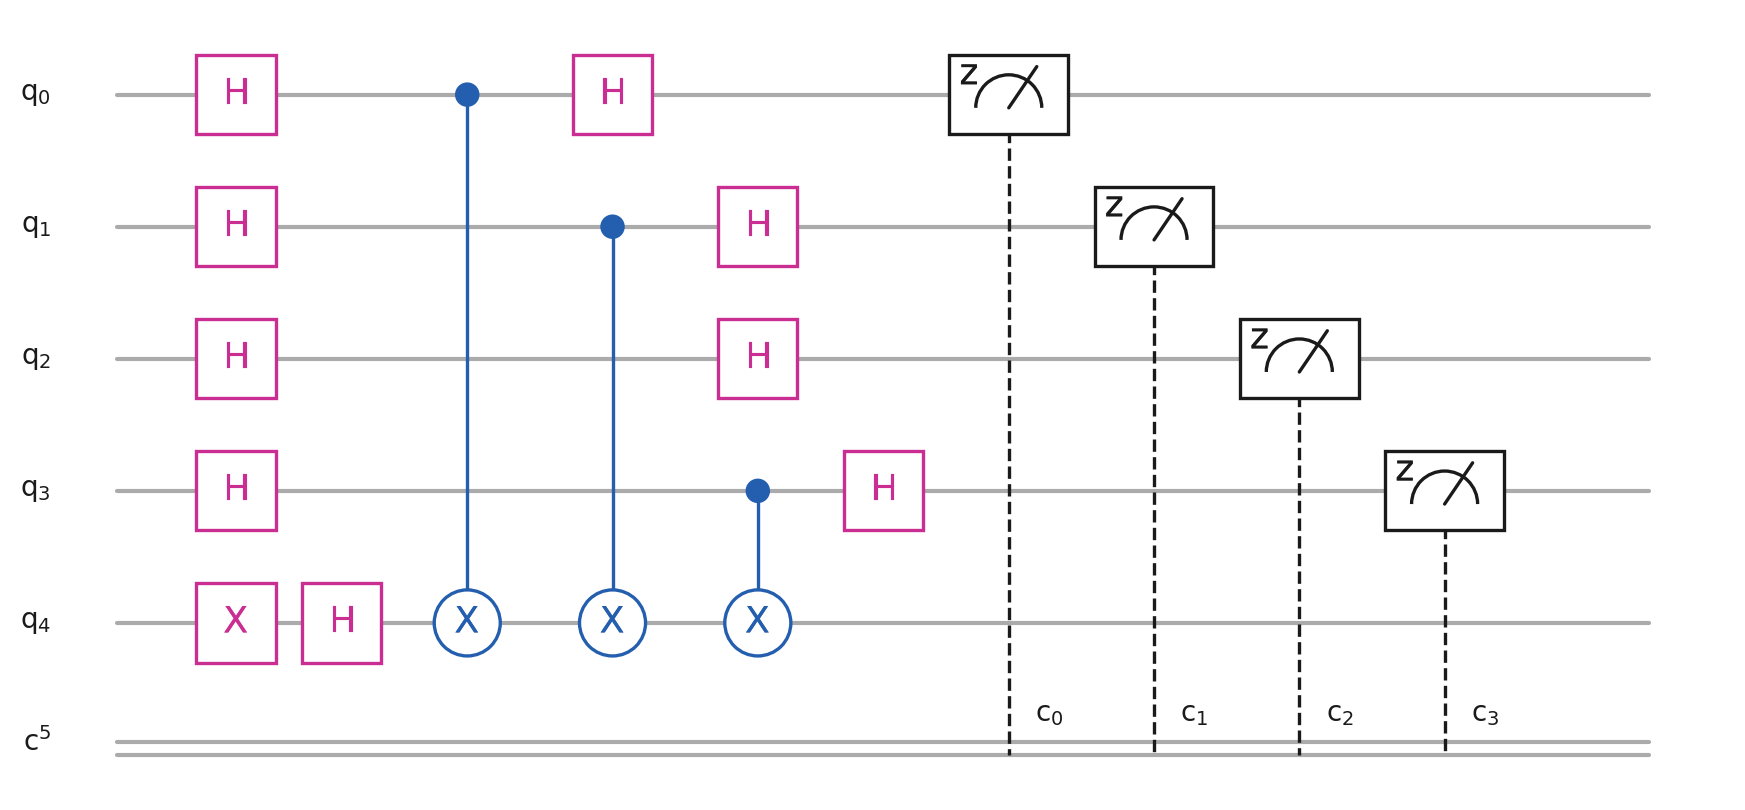

Gate stats: {'total_operations': 17, 'total_gates': 13, 'single_qubit_gates': 10, 'two_qubit_gates': 3, 'multi_qubit_gates': 0, 'clifford_gates': 13, 'non_clifford_gates': 0, 'parametric_gates': 0, 'measurements': 4, 'barriers': 0, 'gate_counts': {'X': 1, 'H': 9, 'CX': 3, 'MEASURE': 4}}


In [2]:
from qpiai_quantum import Circuit

hidden_string = "1011"
n = len(hidden_string)  # number of input qubits

# We need n+1 qubits (n input + 1 ancilla) and n classical bits
qc = Circuit(n + 1, n)

ancilla = n  # last qubit is the ancilla

# ── Stage 1: Prepare ancilla in |−⟩ = H|1⟩ ──
# The ancilla must be in |−⟩ for phase kickback:
#   CX with target |−⟩ flips the phase of the control: |x⟩|−⟩ → (−1)^x |x⟩|−⟩
qc.x(ancilla)
qc.h(ancilla)

# ── Stage 2: Create uniform superposition on input register ──
# |0⟩^n → (1/√2^n) Σ_x |x⟩
for i in range(n):
    qc.h(i)

# ── Stage 3: Apply the inner-product oracle ──
# For each bit position i where s[i] = '1', apply CX(i, ancilla).
# Note: we reverse the string so that the MSB-first output matches the input order.
reversed_s = hidden_string[::-1]
for i, bit in enumerate(reversed_s):
    if bit == '1':
        qc.cx(i, ancilla)

# ── Stage 4: Decode by applying Hadamard to input register ──
for i in range(n):
    qc.h(i)

# ── Stage 5: Measure input qubits ──
for i in range(n):
    qc.measure(i, i)

print("=== Manual BV Circuit for s =", hidden_string, "===")
qc.show()
print("Gate stats:", qc.list_gates())

### 3b. High-Level Construction with `BernsteinVazirani`

The SDK provides a convenient `BernsteinVazirani` class that wraps all five stages above.

Description: Bernstein-Vazirani Algorithm - determine hidden bitstring in a single query via phase kickback

=== BV Circuit (high-level) ===


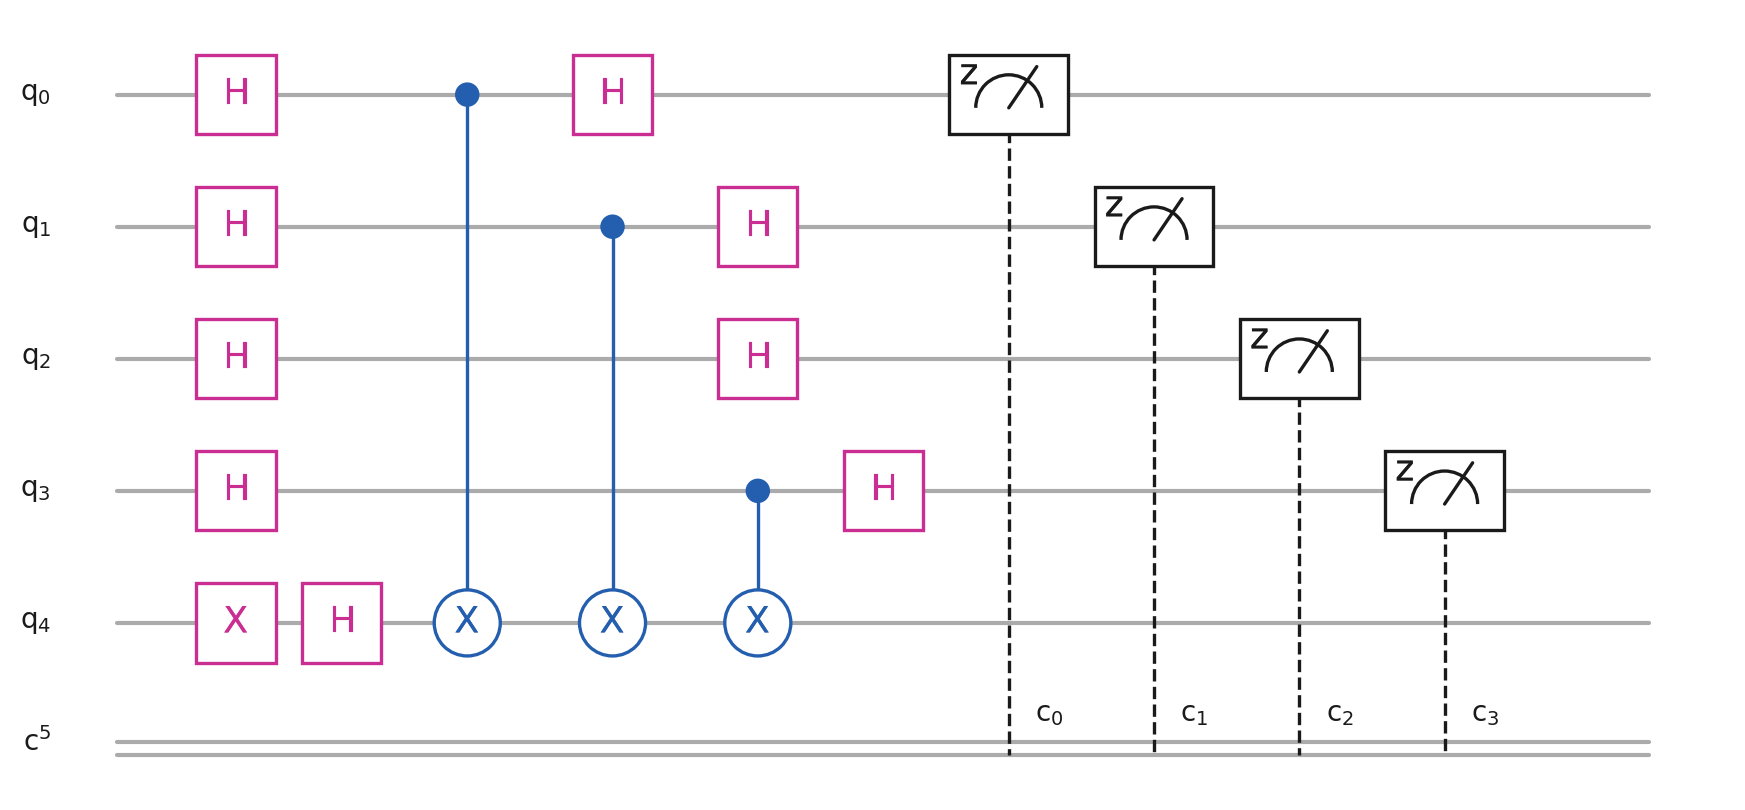

Gate stats: {'total_operations': 17, 'total_gates': 13, 'single_qubit_gates': 10, 'two_qubit_gates': 3, 'multi_qubit_gates': 0, 'clifford_gates': 13, 'non_clifford_gates': 0, 'parametric_gates': 0, 'measurements': 4, 'barriers': 0, 'gate_counts': {'X': 1, 'H': 9, 'CX': 3, 'MEASURE': 4}}


In [3]:
from qpiai_quantum.algorithms import BernsteinVazirani

# Create BV instance for a 4-qubit hidden string
bv = BernsteinVazirani(num_qubits=4, hidden_string="1011")
print("Description:", bv.description)

# Build the circuit
bv_circuit = bv.build_circuit()
print("\n=== BV Circuit (high-level) ===")
bv_circuit.show()
print("Gate stats:", bv_circuit.list_gates())

### 3c. Theoretical Result

Before running, let's check what the algorithm **should** produce:

In [4]:
theory = bv.get_theoretical_result()
print("Theoretical result:")
for key, value in theory.items():
    print(f"  {key}: {value}")

Theoretical result:
  hidden_string: 1011
  expected_counts: {'1011': 1024}
  success_probability: 1.0
  num_oracle_queries: 1
  classical_queries_needed: 4
  speedup: 4x (linear to constant)


## 4. Math: Why the Bernstein-Vazirani Algorithm Works

### The Full State Evolution

**Initial state:**  
$$|\psi_0\rangle = |0\rangle^{\otimes n} |0\rangle$$

**After Stage 1 (ancilla preparation):**  
$$|\psi_1\rangle = |0\rangle^{\otimes n} |{-}\rangle \quad \text{where } |{-}\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

**After Stage 2 (Hadamard on inputs):**  
$$|\psi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle \;|{-}\rangle$$

**After Stage 3 (oracle via phase kickback):**  
The CX gates with target in $|{-}\rangle$ produce:
$$|x_i\rangle|{-}\rangle \xrightarrow{\text{CX}} (-1)^{x_i} |x_i\rangle|{-}\rangle$$

Across all CX gates for positions where $s_i = 1$:
$$|\psi_3\rangle = \frac{1}{\sqrt{2^n}} \sum_{x} (-1)^{s \cdot x} |x\rangle \;|{-}\rangle$$

**After Stage 4 (Hadamard on inputs again):**  
Using the identity $H^{\otimes n} \left(\frac{1}{\sqrt{2^n}} \sum_{x} (-1)^{s \cdot x} |x\rangle\right) = |s\rangle$, we get:
$$|\psi_4\rangle = |s\rangle \;|{-}\rangle$$

**After Stage 5 (measurement):**  
The input register is in the state $|s\rangle$ with **probability 1**. The measurement deterministically yields the hidden string $s$.

### Why Phase Kickback Works

The key trick is using the ancilla in $|{-}\rangle$. When a CNOT gate targets $|{-}\rangle$:

$$\text{CNOT}: |c\rangle|{-}\rangle \to (-1)^c |c\rangle|{-}\rangle$$

The target qubit is **unchanged**, but the control qubit picks up a phase of $(-1)^c$. This is phase kickback — the oracle's output is "kicked back" as a phase on the input register.

### Classical vs Quantum Complexity

| Property | Classical | Quantum (BV) |
|---|---|---|
| Oracle queries needed | $n$ | $1$ |
| Query strategy | One basis vector $e_i$ per query | All basis vectors in superposition |
| Speedup | — | $n \times$ (linear → constant) |

## 5. Experiment: Simulate and Verify

We will now run the BV algorithm for **multiple hidden strings** and verify that the output always matches the hidden string.

> **Simulator default:** `device_name="QpiAI-QSV-Local"`. To use a QPU, change `device_name` to `"QpiAI-Indus-1"` and configure an experiment with the same name in the QpiAI web UI.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [5]:
# Test with several hidden strings
test_strings = ["101", "1011", "110", "0000", "1111"]
shots = 10_000

results = {}
for s in test_strings:
    n = len(s)
    bv_inst = BernsteinVazirani(num_qubits=n, hidden_string=s)
    bv_inst.build_circuit()

    print(f"\n=== Hidden string: {s} (n={n}) ===")
    # Note: experiment_name is only required for cloud executions
    res = bv_inst.run(
        shots=shots,
        device_name="QpiAI-QSV-Local",
    )
    counts = res.get_counts() or {}
    probs = res.get_probabilities() or {}
    results[s] = res

    print("Counts:", counts)
    print("Probabilities:", probs)

    # Verify: the most frequent outcome should be the hidden string
    if counts:
        recovered = max(counts, key=counts.get)
        match = "✅ MATCH" if recovered == s else "❌ MISMATCH"
        print(f"Recovered string: {recovered} {match}")


=== Hidden string: 101 (n=3) ===
Counts: {'101': 10000}
Probabilities: {'101': 1.0}
Recovered string: 101 ✅ MATCH

=== Hidden string: 1011 (n=4) ===
Counts: {'1011': 10000}
Probabilities: {'1011': 1.0}
Recovered string: 1011 ✅ MATCH

=== Hidden string: 110 (n=3) ===
Counts: {'110': 10000}
Probabilities: {'110': 1.0}
Recovered string: 110 ✅ MATCH

=== Hidden string: 0000 (n=4) ===
Counts: {'0000': 10000}
Probabilities: {'0000': 1.0}
Recovered string: 0000 ✅ MATCH

=== Hidden string: 1111 (n=4) ===
Counts: {'1111': 10000}
Probabilities: {'1111': 1.0}
Recovered string: 1111 ✅ MATCH



Plotting histogram for hidden string s = 1011


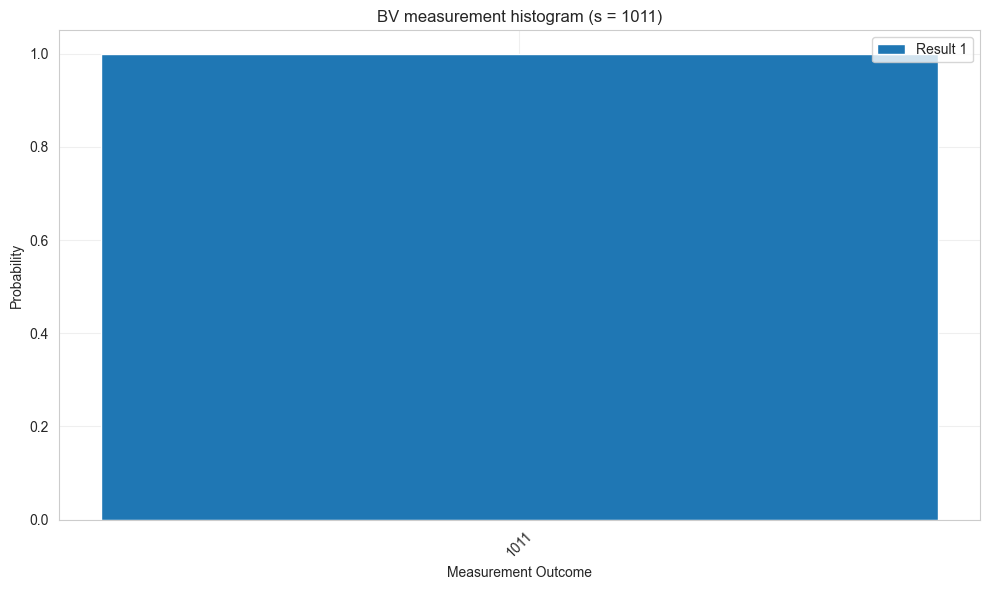

In [6]:
# Visualize the histogram for one example
example_s = "1011"
print(f"\nPlotting histogram for hidden string s = {example_s}")
results[example_s].plot(title=f"BV measurement histogram (s = {example_s})")

### Results Interpretation

In the ideal (noiseless) case, you should observe:

- **A single peak** at the hidden string $s$ with **100% probability** (all 10,000 shots land on the same outcome).
- **No other outcomes** appear in the histogram.

**What the histogram shows:**
- **X-axis:** All possible $n$-bit measurement outcomes.
- **Y-axis:** Probability/count of each outcome.
- **Ideal case:** One bar at the hidden string, nothing else.
- **Noisy QPU:** The correct string still dominates, but other outcomes may appear occasionally.

This confirms the BV algorithm's key property: **one oracle query suffices to determine the entire hidden string**.

### Using `find_hidden_string()` for Convenience

The `BernsteinVazirani` class also provides a `find_hidden_string()` method that runs the circuit and directly returns the recovered hidden string.

In [7]:
bv_auto = BernsteinVazirani(num_qubits=5, hidden_string="10110")
recovered = bv_auto.find_hidden_string(shots=1024)
print(f"Hidden string: 10110")
print(f"Recovered:     {recovered}")
print(f"Match: {'✅' if recovered == '10110' else '❌'}")

Hidden string: 10110
Recovered:     10110
Match: ✅


## 6. Exercises

**Beginner:**

1. Run the BV algorithm with the hidden string `"0000"`. What do you expect to see? Verify by running the circuit.
2. Try different hidden strings of varying lengths (e.g., 2, 3, 6 qubits). Does the algorithm always recover the hidden string in a single run?

**Intermediate:**

3. Build the BV circuit manually (using `Circuit`) for the hidden string `"110"` and display it with `show()`. Identify which CX gates appear in the oracle stage.
4. Compare the theoretical result from `get_theoretical_result()` with the experimental result from `run()`. How do they differ on the simulator?

**Advanced:**

5. **Bent function oracles:** What happens if the oracle implements a function other than $f(x) = s \cdot x \pmod{2}$? Design an oracle for $f(x) = s \cdot x \oplus 1$ and describe the measurement outcome.
6. Prove mathematically that the Hadamard identity $H^{\otimes n}\left(\frac{1}{\sqrt{2^n}}\sum_x (-1)^{s \cdot x}|x\rangle\right) = |s\rangle$ holds. *(Hint: use the definition of the $n$-qubit Hadamard transform and the orthogonality of characters.)*

## 7. Key Takeaways

- The **Bernstein-Vazirani algorithm** determines a hidden bitstring $s$ in **1 oracle query**, compared to $n$ classically.
- The core mechanism is **phase kickback**: the ancilla in $|{-}\rangle$ causes the oracle's output to be encoded as a phase on the input register.
- Two rounds of **Hadamard transforms** (create superposition → decode phase) convert the problem into a single deterministic measurement.
- The QpiAI SDK provides both a **low-level `Circuit` API** for manual construction and a **high-level `BernsteinVazirani` class** with methods like `build_circuit()`, `run()`, `find_hidden_string()`, and `get_theoretical_result()`.
- On the **statevector simulator**, the result is exact (one peak at $s$). On real hardware, noise may introduce small errors, but $s$ remains the dominant outcome.

---
**Thank you for learning with QpiAI!**

In [8]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.32
